# NB1 — SFT-mini: Build the Lab 21 SFT checkpoint inline

**Stack:** Unsloth + LoRA r=16 + bitsandbytes 4-bit base + 1k VN Alpaca, 1 epoch.
Maps to deck §1 (why SFT alone insufficient — motivates the upcoming DPO step) +
deck §3 (DPO will need this SFT checkpoint as initial policy).

> **Mục tiêu:** tạo 1 SFT adapter "đủ tốt" để DPO có gì align lên. Đây là
> Lab 21 thu gọn — nếu bạn đã hoàn thành Lab 21 sibling repo
> ([VinUni-AI20k/Day21-Track3-Finetuning-LLMs-LoRA-QLoRA](https://github.com/VinUni-AI20k/Day21-Track3-Finetuning-LLMs-LoRA-QLoRA)),
> bạn có thể SKIP notebook này và copy adapter cũ vào `adapters/sft-mini/`.
>
> Nếu chưa, notebook này build từ đầu trong ~10 phút trên T4 (15 phút trên Colab CPU runtime — *đừng làm vậy*).

## 0. Setup

In [1]:
import os
from pathlib import Path

# Load environment variables from .env file if it exists
env_path = Path.cwd().parent / ".env" if Path.cwd().name == "notebooks" else Path.cwd() / ".env"
if env_path.exists():
    for _line in env_path.read_text(encoding="utf-8").splitlines():
        _line = _line.strip()
        if _line and not _line.startswith("#") and "=" in _line:
            _key, _val = _line.split("=", 1)
            _val = _val.split("#")[0].strip().strip('"').strip("'")
            os.environ[_key.strip()] = _val

# Tier detection. Defaults to T4 if env not set.
COMPUTE_TIER = os.environ.get("COMPUTE_TIER", "T4").upper()
assert COMPUTE_TIER in ("T4", "BIGGPU"), f"Invalid COMPUTE_TIER: {COMPUTE_TIER}"

# Tier-specific hyperparameters
if COMPUTE_TIER == "T4":
    BASE_MODEL = os.environ.get("BASE_MODEL", "unsloth/Qwen2.5-3B-bnb-4bit")
    MAX_LEN = 512
    PER_DEVICE_BATCH = 1
    GRAD_ACCUM = 8
else:  # BIGGPU
    BASE_MODEL = os.environ.get("BASE_MODEL", "unsloth/Qwen2.5-7B-bnb-4bit")
    MAX_LEN = 1024
    PER_DEVICE_BATCH = 2
    GRAD_ACCUM = 4

SFT_DATASET = os.environ.get("SFT_DATASET", "5CD-AI/Vietnamese-alpaca-cleaned")
SFT_SLICE = 1000
NUM_EPOCHS = 1

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ADAPTER_OUT = REPO_ROOT / "adapters" / "sft-mini"
ADAPTER_OUT.mkdir(parents=True, exist_ok=True)

print(f"COMPUTE_TIER:    {COMPUTE_TIER}")
print(f"BASE_MODEL:      {BASE_MODEL}")
print(f"SFT_DATASET:     {SFT_DATASET}  (slice: {SFT_SLICE})")
print(f"max_seq_length:  {MAX_LEN}")
print(f"effective batch: {PER_DEVICE_BATCH * GRAD_ACCUM}")
print(f"output:          {ADAPTER_OUT}")

COMPUTE_TIER:    T4
BASE_MODEL:      unsloth/Qwen2.5-0.5B-bnb-4bit
SFT_DATASET:     saillab/alpaca-vietnamese-cleaned  (slice: 1000)
max_seq_length:  512
effective batch: 8
output:          D:\project\AI20K\day\day22\Day22-Track3-DPO-Alignment-Lab\adapters\sft-mini


In [2]:
import torch

assert torch.cuda.is_available(), "DPO needs a CUDA GPU. See HARDWARE-GUIDE.md."
gpu = torch.cuda.get_device_properties(0)
print(f"GPU: {gpu.name}  ({gpu.total_memory / 1e9:.1f} GB)")

GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU  (4.3 GB)


## 1. Load base model with Unsloth

Unsloth bundles patched 4-bit kernels — that's how Qwen2.5-3B (or 7B) stays
in T4 / A100 budget. The `FastLanguageModel.from_pretrained` call returns a
4-bit quantized base; `get_peft_model` attaches the LoRA adapter on top.

In [3]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=MAX_LEN,
    dtype=None,                # auto: bf16 on Ampere+, fp16 on Turing
    load_in_4bit=True,
)

# Critical for batch training — Qwen tokenizers ship without pad token.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    print("Set tokenizer.pad_token = eos_token")

if getattr(tokenizer, "chat_template", None) is None:
    tokenizer.chat_template = "{% for message in messages %}{{'<|im_start|>' + message['role'] + '\\n' + message['content'] + '<|im_end|>\\n'}}{% endfor %}{% if add_generation_prompt %}{{'<|im_start|>assistant\\n'}}{% endif %}"
    print("Set default ChatML chat template on tokenizer")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


D:\project\AI20K\day\day22\Day22-Track3-DPO-Alignment-Lab\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🦥 Unsloth Zoo will now patch everything to make training faster!


[unsloth_zoo.log|WARNING]Unsloth: Could not patch trl.trainer.grpo_trainer: Direct module loading failed for UnslothGRPOTrainer: Unexpected optimization option triton.enable_persistent_tma_matmul, known options are ['TYPE_CHECKING', 'enable_auto_functionalized_v2', 'debug', 'disable_progress', 'verbose_progress', 'fx_graph_cache', 'fx_graph_remote_cache', 'autotune_local_cache', 'autotune_remote_cache', 'force_disable_caches', 'sleep_sec_TESTING_ONLY', 'custom_op_default_layout_constraint', 'cpp_wrapper', 'abi_compatible', 'c_shim_version', 'dce', 'static_weight_shapes', 'size_asserts', 'nan_asserts', 'pick_loop_orders', 'inplace_buffers', 'allow_buffer_reuse', 'memory_planning', 'memory_pool', 'benchmark_harness', 'epilogue_fusion', 'epilogue_fusion_first', 'pattern_matcher', 'b2b_gemm_pass', 'post_grad_custom_pre_pass', 'post_grad_custom_post_pass', 'joint_custom_pre_pass', 'joint_custom_post_pass', 'pre_grad_custom_pass', '_pre_fusion_custom_pass', 'split_cat_fx_passes', 'efficient_

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA GeForce RTX 3050 Ti Laptop GPU. Num GPUs = 1. Max memory: 4.0 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.5.1+cu121. CUDA: 8.6. CUDA Toolkit: 12.1. Triton: 3.7.1
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


unsloth/Qwen2.5-0.5B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Set default ChatML chat template on tokenizer


In [4]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    lora_alpha=32,
    lora_dropout=0.0,           # Unsloth supports dropout=0 for free speed
    bias="none",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    use_gradient_checkpointing="unsloth",  # 30% VRAM savings
    random_state=42,
    use_rslora=False,
    loftq_config=None,
)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Unsloth 2026.4.8 patched 24 layers with 24 QKV layers, 24 O layers and 24 MLP layers.


Trainable params: 8,798,208


## 2. Load + format VN Alpaca slice

`5CD-AI/Vietnamese-alpaca-cleaned` is a 50k-row VN Alpaca translation. Lab 21
uses 1k slice for the demo run; we match that exactly so reward gap is comparable.

In [5]:
from datasets import load_dataset

ds = load_dataset(SFT_DATASET, split=f"train[:{SFT_SLICE}]")
print(f"Loaded {len(ds)} rows. Columns: {ds.column_names}")
print(f"\nFirst row:\n{ds[0]}")

Using the latest cached version of the dataset since saillab/alpaca-vietnamese-cleaned couldn't be found on the Hugging Face Hub (offline mode is enabled).


[datasets.load|WARNING]Using the latest cached version of the dataset since saillab/alpaca-vietnamese-cleaned couldn't be found on the Hugging Face Hub (offline mode is enabled).


Found the latest cached dataset configuration 'default' at C:\Users\manhquy\.cache\huggingface\datasets\saillab___alpaca-vietnamese-cleaned\default\0.0.0\a64ef441c9b10445d957a404d9ce6f5fd4d84254 (last modified on Fri Jun 26 14:39:47 2026).


[datasets.packaged_modules.cache.cache|WARNING]Found the latest cached dataset configuration 'default' at C:\Users\manhquy\.cache\huggingface\datasets\saillab___alpaca-vietnamese-cleaned\default\0.0.0\a64ef441c9b10445d957a404d9ce6f5fd4d84254 (last modified on Fri Jun 26 14:39:47 2026).


Loaded 1000 rows. Columns: ['instruction', 'input', 'output']

First row:
{'instruction': 'Đưa ra một mô tả về một con vật, xác định loại động vật đó là gì.', 'input': ' Loài vật này có chiếc cổ dài, linh hoạt và mỏ hẹp, nhọn. Nó có chân dài và bàn chân có màng, và nó ăn chủ yếu là cá.', 'output': ' Con vật được mô tả có khả năng là một con diệc.'}


In [6]:
# Alpaca → ChatML format (Qwen2.5's native template)
def format_alpaca_to_chat(row):
    messages = []
    if row.get("instruction"):
        prompt = row["instruction"]
        if row.get("input"):
            prompt += "\n\n" + row["input"]
        messages.append({"role": "user", "content": prompt})
    if row.get("output"):
        messages.append({"role": "assistant", "content": row["output"]})
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    return {"text": text}


ds_formatted = ds.map(format_alpaca_to_chat, remove_columns=ds.column_names)
print(f"\nSample formatted text (first 500 chars):\n{ds_formatted[0]['text'][:500]}")

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map: 100%|██████████| 1000/1000 [00:00<00:00, 9299.10 examples/s]

Map: 100%|██████████| 1000/1000 [00:00<00:00, 7585.75 examples/s]


Sample formatted text (first 500 chars):
<|im_start|>user
Đưa ra một mô tả về một con vật, xác định loại động vật đó là gì.

 Loài vật này có chiếc cổ dài, linh hoạt và mỏ hẹp, nhọn. Nó có chân dài và bàn chân có màng, và nó ăn chủ yếu là cá.<|im_end|>
<|im_start|>assistant
 Con vật được mô tả có khả năng là một con diệc.<|im_end|>



## 3. Train SFT-mini

In [7]:
from trl import SFTTrainer, SFTConfig

sft_config = SFTConfig(
    output_dir=str(ADAPTER_OUT.parent / "sft-mini-checkpoints"),
    per_device_train_batch_size=PER_DEVICE_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    num_train_epochs=NUM_EPOCHS,
    learning_rate=2e-4,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=10,
    save_strategy="no",        # Save only at the end via trainer.model.save_pretrained
    optim="adamw_8bit",
    bf16=torch.cuda.is_bf16_supported(),
    fp16=not torch.cuda.is_bf16_supported(),
    seed=42,
    max_length=MAX_LEN,
    dataset_text_field="text",
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    args=sft_config,
    train_dataset=ds_formatted,
)

C:\Users\manhquy\AppData\Local\Temp\unsloth_compiled_cache\UnslothSFTTrainer.py:845: UserWarning: Padding-free training is enabled, but the attention implementation is not set to 'flash_attention_2'. Padding-free training flattens batches into a single sequence, and 'flash_attention_2' is the only known attention mechanism that reliably supports this. Using other implementations may lead to unexpected behavior. To ensure compatibility, set `attn_implementation='flash_attention_2'` in the model configuration, or verify that your attention mechanism can handle flattened sequences.
  warnings.warn(


Unsloth: Tokenizing ["text"]:   0%|          | 0/1000 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"]: 100%|██████████| 1000/1000 [00:00<00:00, 1517.11 examples/s]

Unsloth: Tokenizing ["text"]: 100%|██████████| 1000/1000 [00:00<00:00, 1471.81 examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


In [8]:
train_result = trainer.train()
print(f"\nFinal train loss: {train_result.training_loss:.4f}")

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,000 | Num Epochs = 1 | Total steps = 125
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 8,798,208 of 502,830,976 (1.75% trained)


Step,Training Loss
10,2.577300
20,2.291300
30,2.117000
40,2.216800
50,2.022600
60,2.029200
70,1.985800
80,2.060300
90,2.088200
100,2.060500



Final train loss: 2.1181


### 3a. Plot loss curve (deliverable: `02_sft_loss.png`)

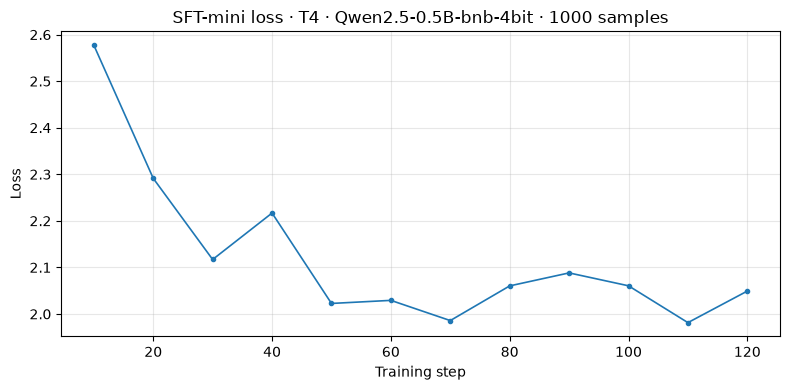

In [9]:
import matplotlib.pyplot as plt

losses = [log["loss"] for log in trainer.state.log_history if "loss" in log]
steps = [log["step"] for log in trainer.state.log_history if "loss" in log]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(steps, losses, marker="o", markersize=3, linewidth=1.2)
ax.set_xlabel("Training step")
ax.set_ylabel("Loss")
ax.set_title(f"SFT-mini loss · {COMPUTE_TIER} · {BASE_MODEL.split('/')[-1]} · {SFT_SLICE} samples")
ax.grid(True, alpha=0.3)
fig.tight_layout()
screenshot_dir = REPO_ROOT / "submission" / "screenshots"
screenshot_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(screenshot_dir / "02-sft-loss.png", dpi=120)
plt.show()

## 4. Save adapter + sanity-check generation

In [10]:
trainer.model.save_pretrained(str(ADAPTER_OUT))
tokenizer.save_pretrained(str(ADAPTER_OUT))
print(f"Saved SFT adapter to {ADAPTER_OUT}")

D:\project\AI20K\day\day22\Day22-Track3-DPO-Alignment-Lab\.venv\Lib\site-packages\peft\utils\save_and_load.py:372: UserWarning: Could not find a config file in unsloth/Qwen2.5-0.5B-bnb-4bit - will assume that the vocabulary was not modified.
  warnings.warn(


Saved SFT adapter to D:\project\AI20K\day\day22\Day22-Track3-DPO-Alignment-Lab\adapters\sft-mini


In [11]:
# Sanity: generate 1 sample to confirm the adapter loaded correctly.
FastLanguageModel.for_inference(model)
prompt = "Giải thích ngắn gọn (3-4 câu) thuật toán quicksort hoạt động thế nào."
messages = [{"role": "user", "content": prompt}]
inputs = tokenizer.apply_chat_template(
    messages, return_tensors="pt", add_generation_prompt=True
).to("cuda")
with torch.no_grad():
    out = model.generate(input_ids=inputs, max_new_tokens=200, do_sample=False)
generated = tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True)
print(f"PROMPT: {prompt}\n")
print(f"SFT-mini response:\n{generated}")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


PROMPT: Giải thích ngắn gọn (3-4 câu) thuật toán quicksort hoạt động thế nào.

SFT-mini response:
 Quicksort là một thuật toán sắp xếp dữ liệu có thể được sử dụng để sắp xếp các phần tử trong một danh sách. Nó hoạt động như thế: 1. Tạo một danh sách tạm thời chứa các phần tử đã sắp xếp. 2. Tạo một danh sách tạm thời chứa các phần tử chưa được sắp xếp. 3. Tạo một danh sách tạm thời chứa các phần tử đã được sắp xếp. 4. Tạo một danh sách tạm thời chứa các phần tử chưa được sắp xếp. 5. Tạo một danh sách tạm thời chứa các phần tử đã được sắp xếp. 6. Tạo một danh sách tạm thời chứa các phần tử chưa được sắp xếp. 7. Tạo một danh sách tạm thời chứa các phần tử đã được sắp xếp. 8. Tạo một danh sách tạm thời chứa các phần tử đã được sắp xếp. 9. Tạo một danh sách tạm thời chứa các phần tử đã được


## 5. Vibe-coding callout

Bạn vừa tái tạo Lab 21 trong ~10 phút. Một câu hỏi để brainstorm:

> **Thật ra, bạn cần *bao nhiêu* SFT để DPO có ý nghĩa?**
>
> Thử thay `SFT_SLICE = 1000` → `100`. Re-run NB1 → NB3 với SFT yếu hơn.
> Quan sát: reward gap có còn tăng được không? Output coherent không?
>
> Đây là 1 design decision *think-hard zone* (xem VIBE-CODING.md): không có
> đáp án sẵn trong deck. Hypothesize trước, train sau, viết kết quả vào
> `submission/REFLECTION.md` § 6.

**Next:** NB2 — load + format preference data.